# Généralisation - Détection et classification avancée de navires

Ce notebook répond au README `Sujet5/Généralisation/README.md` avec une priorité volontaire : comprendre et préparer la donnée avant de construire une vraie solution de vision.

Ce que l'on peut faire maintenant : analyser les métadonnées, annotations, résultats de détection, zones militaires et préparer un MVP data.

Ce que l'on ne peut pas faire sérieusement sans images réelles : entraîner YOLO/Faster R-CNN, mesurer une vraie mAP, comparer visuellement des prédictions.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

candidate_dirs = [Path('.'), Path('Sujet5/Généralisation')]
DATA_DIR = next(path for path in candidate_dirs if (path / 'images_metadata_large.csv').exists())
METADATA_PATH = DATA_DIR / 'images_metadata_large.csv'
ANNOTATIONS_PATH = DATA_DIR / 'annotations_large.json'
DETECTIONS_PATH = DATA_DIR / 'detection_results.csv'
ZONES_PATH = DATA_DIR / 'military_zones.csv'

images = pd.read_csv(METADATA_PATH)
detections = pd.read_csv(DETECTIONS_PATH)
zones = pd.read_csv(ZONES_PATH)
with open(ANNOTATIONS_PATH, 'r', encoding='utf-8') as f:
    coco = json.load(f)

images.head()

,image_id,file_name,date,time,zone_id,zone_name,coordinates,country,risk_level,resolution,source,num_ships,ship_types,cloud_cover,url
0,IMG-000,satellite_000.jpg,2026-08-31,17:17:58,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...
1,IMG-001,satellite_001.jpg,2026-04-17,04:54:56,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,10m,Maxar,2,"Destroyer, Navire de guerre",39.0,https://example.com/satellite_images/satellite...
2,IMG-002,satellite_002.jpg,2026-03-02,15:20:53,ZONE-009,Base navale de Yokosuka,"35.4,139.7",Japan,High,1m,Sentinel-2,4,"Navire de soutien, Chalutier, Porte-avions, Na...",25.6,https://example.com/satellite_images/satellite...
3,IMG-003,satellite_003.jpg,2026-08-17,16:27:15,ZONE-012,Détroit d'Ormuz,"25.0,56.0",International,Critical,0.5m,PlanetScope,0,Aucun,27.3,https://example.com/satellite_images/satellite...
4,IMG-004,satellite_004.jpg,2026-10-03,08:53:49,ZONE-015,Mer Baltique,"55.0,20.0",International,Medium,1m,Sentinel-2,3,"Destroyer, Pétrolier, Frégate",32.7,https://example.com/satellite_images/satellite...


## 1. Analyse des métadonnées

On regarde les sources d'images, la résolution moyenne et le nombre d'images avec une couverture nuageuse élevée.

In [2]:
top_sources = images['source'].value_counts().head(3)

# La résolution est stockée en texte, par exemple "0.5m", "1m", "10m".
images['resolution_m'] = images['resolution'].str.replace('m', '', regex=False).astype(float)
resolution_mean = images['resolution_m'].mean()
cloudy_images = (images['cloud_cover'] > 30).sum()

print('Top 3 des sources d images :')
display(top_sources.to_frame('nombre_images'))
print(f"Résolution moyenne : {resolution_mean:.2f} m")
print(f"Images avec couverture nuageuse > 30% : {cloudy_images} / {len(images)}")

Top 3 des sources d images :


,nombre_images
source,
Maxar,28
Sentinel-2,21
PlanetScope,19


Résolution moyenne : 4.62 m
Images avec couverture nuageuse > 30% : 45 / 100


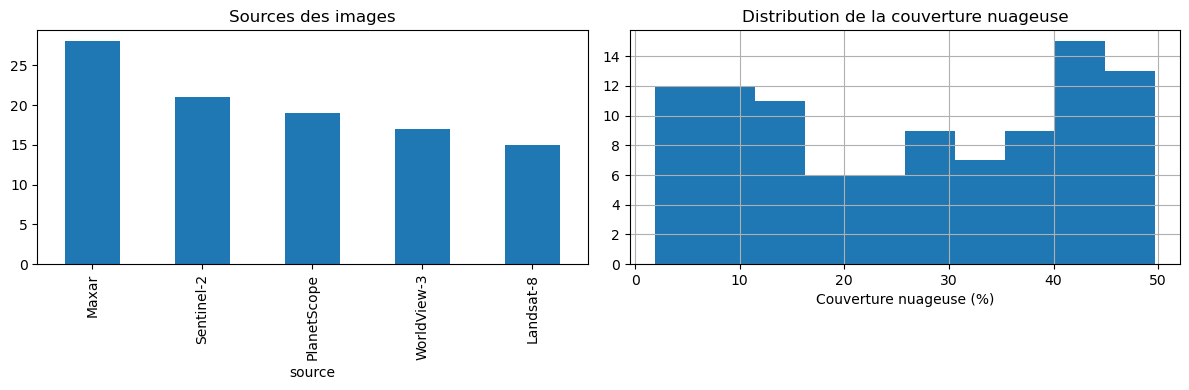

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
images['source'].value_counts().plot(kind='bar', ax=axes[0], title='Sources des images')
images['cloud_cover'].hist(bins=10, ax=axes[1])
axes[1].set_title('Distribution de la couverture nuageuse')
axes[1].set_xlabel('Couverture nuageuse (%)')
plt.tight_layout()

## 2. Analyse des annotations

On transforme les annotations COCO en table exploitable. Pour définir les navires militaires, on utilise une définition stricte : navire de guerre, frégate, destroyer, porte-avions, sous-marin, croiseur et corvette.

Les navires de soutien et bâtiments de débarquement peuvent être discutés avec un humain métier. Dans les résultats fournis, ils ne sont pas marqués comme militaires.

In [4]:
categories = pd.DataFrame(coco['categories'])
annotations = pd.DataFrame(coco['annotations'])
category_map = dict(zip(categories['id'], categories['name']))
annotations['category_name'] = annotations['category_id'].map(category_map)

bbox = pd.DataFrame(annotations['bbox'].tolist(), columns=['x', 'y', 'width', 'height'])
annotations = pd.concat([annotations.drop(columns=['bbox']), bbox], axis=1)
annotations['bbox_area_pct'] = annotations['width'] * annotations['height'] * 100

military_classes = ['Navire de guerre', 'Frégate', 'Destroyer', 'Porte-avions', 'Sous-marin', 'Croiseur', 'Corvette']
annotations['is_military'] = annotations['category_name'].isin(military_classes)

nb_military_annotations = annotations['is_military'].sum()
print(f"Nombre de navires militaires annotés : {nb_military_annotations} / {len(annotations)}")

type_distribution = annotations['category_name'].value_counts(normalize=True).mul(100).round(2)
display(type_distribution.to_frame('pourcentage'))

bbox_by_type = annotations.groupby('category_name')['bbox_area_pct'].mean().sort_values(ascending=False).round(2)
display(bbox_by_type.to_frame('surface_moyenne_pct'))

Nombre de navires militaires annotés : 134 / 256


,pourcentage
category_name,
Navire de guerre,10.94
Navire civil,8.98
Destroyer,8.98
Cargo,8.59
Frégate,8.20
Navire de soutien,7.81
Chalutier,7.81
Pétrolier,7.42
Bâtiment de débarquement,7.03


,surface_moyenne_pct
category_name,
Pétrolier,3.38
Corvette,3.31
Bâtiment de débarquement,3.06
Croiseur,3.05
Sous-marin,2.86
Navire de soutien,2.68
Frégate,2.59
Destroyer,2.45
Navire civil,2.40


## 3. Fusion des métadonnées et des résultats de détection

On fusionne les informations image avec les détections. Cela donne une table très utile pour un MVP : une ligne par navire détecté, avec contexte géographique et niveau de risque.

In [5]:
merged = detections.merge(
    images.drop(columns=['file_name', 'zone_name', 'risk_level'], errors='ignore'),
    on='image_id',
    how='left',
    suffixes=('', '_image')
)

print(f"Nombre de détections : {len(detections)}")
print(f"Nombre d'images dans les métadonnées : {len(images)}")
print(f"Nombre de lignes après fusion : {len(merged)}")

detections_per_image = detections.groupby('image_id').size().sort_values(ascending=False)
print(f"Nombre moyen de détections par image détectée : {detections_per_image.mean():.2f}")
print(f"Image avec le plus grand nombre de détections : {detections_per_image.index[0]} ({detections_per_image.iloc[0]} détections)")

display(merged.head())

Nombre de détections : 256
Nombre d'images dans les métadonnées : 100
Nombre de lignes après fusion : 256
Nombre moyen de détections par image détectée : 3.12
Image avec le plus grand nombre de détections : IMG-000 (5 détections)


,detection_id,image_id,file_name,timestamp,bbox,category,confidence,is_military,zone_id,zone_name,...,zone_id_image,coordinates,country,resolution,source,num_ships,ship_types,cloud_cover,url,resolution_m
0,DET-000-00001,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3766847153545144,0.602830810224785,0.2798675...",Navire de guerre,0.84,True,ZONE-002,Base navale de Norfolk,...,ZONE-002,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...,1.0
1,DET-000-00002,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.6730405409693083,0.37685587994514613,0.29411...",Navire civil,0.72,False,ZONE-002,Base navale de Norfolk,...,ZONE-002,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...,1.0
2,DET-000-00003,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3499607760017571,0.6063398574692226,0.244706...",Bâtiment de débarquement,0.96,False,ZONE-002,Base navale de Norfolk,...,ZONE-002,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...,1.0
3,DET-000-00004,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.6159782694606443,0.45954657746946426,0.27517...",Destroyer,0.89,True,ZONE-002,Base navale de Norfolk,...,ZONE-002,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...,1.0
4,DET-000-00005,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.7200515440830189,0.2160546184846373,0.135625...",Pétrolier,0.90,False,ZONE-002,Base navale de Norfolk,...,ZONE-002,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...,1.0


## 4. Entraînement d'un modèle de détection

État réaliste : non mesurable pour le moment.

Raison : les annotations sont présentes, mais les images réelles ne sont pas dans le dossier. Les URLs du CSV pointent vers `example.com`, donc on ne peut pas entraîner ou évaluer YOLO/Faster R-CNN honnêtement à ce stade.

Ce que l'on peut faire maintenant : préparer la séparation train/validation/test sur les IDs d'images.

In [6]:
image_ids = pd.Series([img['id'] for img in coco['images']], name='coco_image_id').sample(frac=1, random_state=42).reset_index(drop=True)
n = len(image_ids)
train_ids = image_ids.iloc[:int(0.70*n)]
val_ids = image_ids.iloc[int(0.70*n):int(0.85*n)]
test_ids = image_ids.iloc[int(0.85*n):]

print(f"Train : {len(train_ids)} images")
print(f"Validation : {len(val_ids)} images")
print(f"Test : {len(test_ids)} images")
print('mAP test : non mesurable tant que les images ne sont pas disponibles localement')

Train : 70 images
Validation : 15 images
Test : 15 images
mAP test : non mesurable tant que les images ne sont pas disponibles localement


## 5. Détection sur de nouvelles images

Même limite : on ne peut pas appliquer un modèle sans images locales et sans modèle entraîné.

Action manuelle à faire : récupérer 5 images réelles depuis une source ouverte, les placer dans un dossier `images/`, puis lancer un modèle de détection.

In [7]:
test_candidates = images.sample(5, random_state=42)[['image_id', 'file_name', 'zone_name', 'risk_level', 'url']]
test_candidates

,image_id,file_name,zone_name,risk_level,url
83,IMG-083,satellite_083.jpg,Mer de Chine Méridionale,Critical,https://example.com/satellite_images/satellite...
53,IMG-053,satellite_053.jpg,Canal de Suez,Medium,https://example.com/satellite_images/satellite...
70,IMG-070,satellite_070.jpg,Port de Rotterdam,Low,https://example.com/satellite_images/satellite...
45,IMG-045,satellite_045.jpg,Mer Baltique,Medium,https://example.com/satellite_images/satellite...
44,IMG-044,satellite_044.jpg,Port de Rotterdam,Low,https://example.com/satellite_images/satellite...


## 6. Optimisation du modèle

Non applicable pour l'instant. Les idées à garder pour la suite :

- commencer par YOLOv8 nano ou small pour aller vite ;
- utiliser augmentation simple : rotations, flips, luminosité ;
- mesurer d'abord un baseline, puis optimiser ;
- éviter de perdre du temps sur l'optimisation avant d'avoir des images propres.

## 7. Classification binaire militaire / civil

Avec les résultats fournis, la colonne `is_military` existe déjà. On peut donc construire un premier classifieur très simple à partir des caractéristiques de bbox et de contexte.

Ce n'est pas encore une classification visuelle : c'est une base tabulaire pour comprendre les signaux disponibles.

In [8]:
bbox_det = detections['bbox'].str.split(',', expand=True).astype(float)
bbox_det.columns = ['x', 'y', 'width', 'height']
features = pd.concat([detections[['detection_id', 'category', 'confidence', 'is_military', 'risk_level']], bbox_det], axis=1)
features['bbox_area_pct'] = features['width'] * features['height'] * 100
features['bbox_ratio'] = features['width'] / features['height']

print('Répartition civil / militaire dans detection_results.csv :')
display(features['is_military'].value_counts().to_frame('nombre_detections'))
display(features.head())

Répartition civil / militaire dans detection_results.csv :


,nombre_detections
is_military,
True,134
False,122


,detection_id,category,confidence,is_military,risk_level,x,y,width,height,bbox_area_pct,bbox_ratio
0,DET-000-00001,Navire de guerre,0.84,True,High,0.376685,0.602831,0.279868,0.066771,1.868713,4.191431
1,DET-000-00002,Navire civil,0.72,False,High,0.673041,0.376856,0.294114,0.236019,6.941634,1.246145
2,DET-000-00003,Bâtiment de débarquement,0.96,False,High,0.349961,0.606340,0.244707,0.201743,4.936774,1.212964
3,DET-000-00004,Destroyer,0.89,True,High,0.615978,0.459547,0.275174,0.126834,3.490132,2.169567
4,DET-000-00005,Pétrolier,0.90,False,High,0.720052,0.216055,0.135625,0.260832,3.537541,0.519971


## 8. Classification multi-classes

On peut déjà observer la répartition par type. L'entraînement multi-classes visuel sera pertinent seulement après récupération des images et extraction des crops de navires.

,nombre_detections
category,
Navire de guerre,28
Navire civil,23
Destroyer,23
Cargo,22
Frégate,21
Navire de soutien,20
Chalutier,20
Pétrolier,19
Bâtiment de débarquement,18


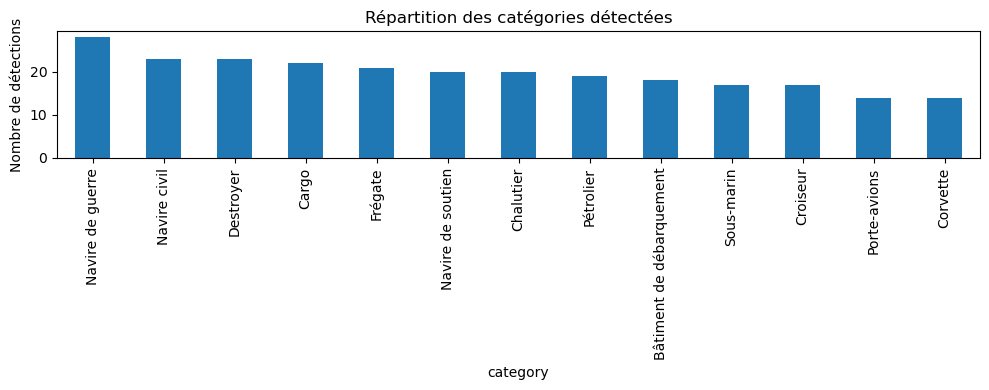

In [9]:
multi_counts = detections['category'].value_counts()
display(multi_counts.to_frame('nombre_detections'))

multi_counts.plot(kind='bar', figsize=(10, 4), title='Répartition des catégories détectées')
plt.ylabel('Nombre de détections')
plt.tight_layout()

## 9. Analyse des erreurs de classification

Impossible à mesurer directement sans prédictions d'un modèle comparées à une vérité terrain visuelle.

Risques probables à anticiper :

- frégate confondue avec destroyer ou croiseur ;
- navire civil long confondu avec bâtiment militaire ;
- petits navires mal détectés en résolution 10m ;
- erreurs fortes en présence de nuages, ombres ou infrastructures portuaires.

## 10. Détection de navires dans des zones militaires

Les détections contiennent déjà `zone_id`, `zone_name` et `risk_level`. Le fichier `military_zones.csv` utilise des IDs `MIL-*`, donc il ne se joint pas directement aux `ZONE-*`. Pour un MVP, on croise par nom ou proximité de coordonnées après nettoyage.

In [10]:
print(f"Nombre de zones militaires fournies : {len(zones)}")
print(f"Zones actives : {zones['active'].sum()} / {len(zones)}")

military_detections = detections[detections['is_military']]
print(f"Navires militaires détectés dans detection_results.csv : {len(military_detections)}")

display(military_detections[['detection_id', 'image_id', 'category', 'confidence', 'zone_name', 'risk_level']].head(10))

Nombre de zones militaires fournies : 20
Zones actives : 11 / 20
Navires militaires détectés dans detection_results.csv : 134


,detection_id,image_id,category,confidence,zone_name,risk_level
0,DET-000-00001,IMG-000,Navire de guerre,0.84,Base navale de Norfolk,High
3,DET-000-00004,IMG-000,Destroyer,0.89,Base navale de Norfolk,High
5,DET-001-00006,IMG-001,Destroyer,0.94,Base navale de Norfolk,High
6,DET-001-00007,IMG-001,Navire de guerre,0.82,Base navale de Norfolk,High
9,DET-002-00010,IMG-002,Porte-avions,0.78,Base navale de Yokosuka,High
10,DET-002-00011,IMG-002,Navire de guerre,0.83,Base navale de Yokosuka,High
11,DET-004-00012,IMG-004,Destroyer,0.96,Mer Baltique,Medium
13,DET-004-00014,IMG-004,Frégate,0.96,Mer Baltique,Medium
15,DET-005-00016,IMG-005,Destroyer,0.82,Base navale de Rota,High
17,DET-005-00018,IMG-005,Frégate,0.97,Base navale de Rota,High


Carte interactive : faisable avec `folium`, mais elle sera plus propre après harmonisation des coordonnées entre images, détections et zones militaires. Pour l'instant, les détections ont une zone mais pas leurs propres coordonnées géographiques exactes.

## 11. Analyse temporelle

On peut déjà compter les détections par mois et par zone. La corrélation avec des événements géopolitiques devra être faite manuellement ensuite, car elle demande des sources externes datées.

/var/folders/sf/m78jr1b16jxb5smh8zs29f0h0000gq/T/ipykernel_59805/3773606372.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  detections_time['month'] = detections_time['timestamp'].dt.to_period('M').astype(str)


,nombre_detections
month,
2026-01,20
2026-02,24
2026-03,25
2026-04,35
2026-05,23
2026-06,30
2026-07,9
2026-08,12
2026-09,12


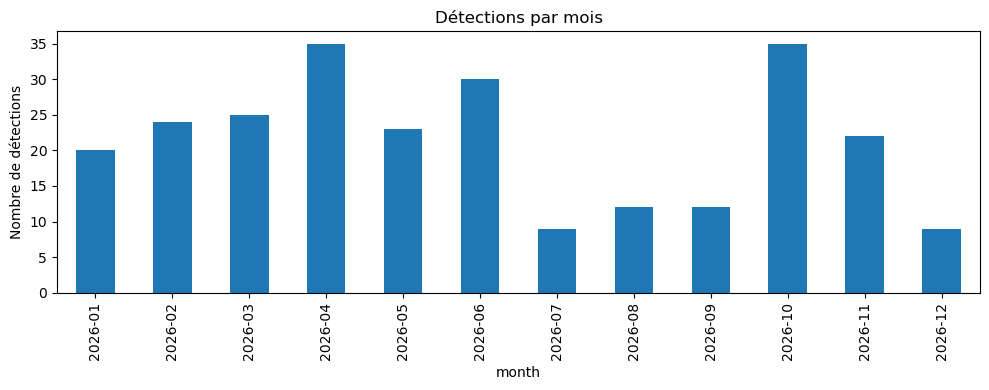

In [11]:
detections_time = detections.copy()
detections_time['timestamp'] = pd.to_datetime(detections_time['timestamp'])
detections_time['month'] = detections_time['timestamp'].dt.to_period('M').astype(str)

monthly = detections_time.groupby('month').size()
display(monthly.to_frame('nombre_detections'))

monthly.plot(kind='bar', figsize=(10, 4), title='Détections par mois')
plt.ylabel('Nombre de détections')
plt.tight_layout()

## 12. Détection d'anomalies géospatiales

On peut proposer une première définition simple :

- civil en zone critique = à regarder si la zone est militaire ou très sensible ;
- militaire en zone non critique = pas forcément suspect, mais intéressant si éloigné des bases connues ;
- militaire en zone critique avec forte confiance = priorité haute.

In [12]:
anomalies = detections.copy()
anomalies['priority_reason'] = ''
anomalies.loc[(~anomalies['is_military']) & (anomalies['risk_level'] == 'Critical'), 'priority_reason'] = 'Civil en zone critique'
anomalies.loc[(anomalies['is_military']) & (anomalies['risk_level'] == 'Critical') & (anomalies['confidence'] >= 0.85), 'priority_reason'] = 'Militaire haute confiance en zone critique'
anomalies.loc[(anomalies['is_military']) & (anomalies['risk_level'] == 'High') & (anomalies['confidence'] >= 0.90), 'priority_reason'] = 'Militaire haute confiance en zone à risque élevé'

priority_cases = anomalies[anomalies['priority_reason'] != ''].sort_values(['risk_level', 'confidence'], ascending=[True, False])
display(priority_cases[['detection_id', 'category', 'confidence', 'is_military', 'zone_name', 'risk_level', 'priority_reason']].head(20))

,detection_id,category,confidence,is_military,zone_name,risk_level,priority_reason
29,DET-008-00030,Navire de guerre,1.00,True,Détroit d'Ormuz,Critical,Militaire haute confiance en zone critique
43,DET-011-00044,Chalutier,1.00,False,Détroit de Malacca,Critical,Civil en zone critique
86,DET-027-00087,Pétrolier,0.99,False,Mer de Chine Méridionale,Critical,Civil en zone critique
187,DET-069-00188,Navire de soutien,0.99,False,Mer de Chine Méridionale,Critical,Civil en zone critique
109,DET-034-00110,Chalutier,0.98,False,Mer de Chine Méridionale,Critical,Civil en zone critique
142,DET-051-00143,Frégate,0.98,True,Détroit de Malacca,Critical,Militaire haute confiance en zone critique
154,DET-055-00155,Porte-avions,0.98,True,Détroit de Malacca,Critical,Militaire haute confiance en zone critique
209,DET-083-00210,Pétrolier,0.98,False,Mer de Chine Méridionale,Critical,Civil en zone critique
253,DET-099-00254,Corvette,0.98,True,Mer de Chine Méridionale,Critical,Militaire haute confiance en zone critique
48,DET-014-00049,Navire de guerre,0.97,True,Golfe Persique,Critical,Militaire haute confiance en zone critique


## 13. Pipeline complet envisagé

Version MVP data, réalisable tout de suite :

1. charger les métadonnées ;
2. charger les détections ;
3. normaliser les catégories ;
4. marquer civil / militaire ;
5. ajouter un score de priorité ;
6. sortir un tableau des observations à regarder en premier.

Version complète, après récupération des images :

1. charger une image satellite ;
2. détecter les navires ;
3. classifier les navires ;
4. croiser avec les zones sensibles ;
5. générer un rapport et une alerte.

In [13]:
def compute_priority_score(row):
    score = 0
    if row['is_military']:
        score += 40
    if row['risk_level'] == 'Critical':
        score += 25
    elif row['risk_level'] == 'High':
        score += 15
    if row['confidence'] >= 0.85:
        score += 15
    if row['category'] in ['Porte-avions', 'Sous-marin', 'Destroyer', 'Croiseur']:
        score += 20
    return score

scored = detections.copy()
scored['priority_score'] = scored.apply(compute_priority_score, axis=1)
scored = scored.sort_values('priority_score', ascending=False)

display(scored[['detection_id', 'image_id', 'category', 'confidence', 'is_military', 'zone_name', 'risk_level', 'priority_score']].head(15))

,detection_id,image_id,category,confidence,is_military,zone_name,risk_level,priority_score
49,DET-014-00050,IMG-014,Destroyer,0.87,True,Golfe Persique,Critical,100
107,DET-034-00108,IMG-034,Sous-marin,0.97,True,Mer de Chine Méridionale,Critical,100
188,DET-069-00189,IMG-069,Porte-avions,0.89,True,Mer de Chine Méridionale,Critical,100
166,DET-062-00167,IMG-062,Croiseur,0.87,True,Mer de Chine Méridionale,Critical,100
155,DET-055-00156,IMG-055,Sous-marin,0.93,True,Détroit de Malacca,Critical,100
154,DET-055-00155,IMG-055,Porte-avions,0.98,True,Détroit de Malacca,Critical,100
72,DET-022-00073,IMG-022,Destroyer,0.96,True,Détroit de Malacca,Critical,100
78,DET-024-00079,IMG-024,Destroyer,0.94,True,Détroit d'Ormuz,Critical,100
21,DET-006-00022,IMG-006,Porte-avions,0.89,True,Détroit de Malacca,Critical,100
220,DET-086-00221,IMG-086,Croiseur,0.89,True,Détroit de Malacca,Critical,100


## 14. Optimisation des performances

À garder pour plus tard :

- mesurer le temps de traitement par image ;
- choisir un modèle léger pour le MVP ;
- exporter en ONNX si besoin ;
- quantifier le modèle si la mémoire devient un problème ;
- prioriser la qualité des données avant le tuning.

## 15. API externes utiles

À récupérer si le temps le permet :

- OpenStreetMap / Overpass : enrichir les zones portuaires ;
- météo : nuages, visibilité, conditions de prise de vue ;
- données géopolitiques publiques : exercices navals, tensions, événements ;
- AIS public quand disponible : comparer présence détectée et présence déclarée.

Ces sources ne remplacent pas la détection. Elles aident à interpréter le signal.

## 16 à 18. Benchmarking et rapport global

Pas réaliste immédiatement sans images et modèle entraîné.

Ce qu'on peut annoncer proprement :

- baseline visé : YOLOv8 nano/small ;
- modèle alternatif : Faster R-CNN si temps disponible ;
- métriques à produire : mAP, précision, rappel, F1, temps/image ;
- rapport final : données, méthode, limites, top observations, pistes d'amélioration.

## Plan d'action data prioritaire

1. Garder les fichiers fournis comme socle de MVP.
2. Documenter clairement que les URLs sont factices.
3. Récupérer un petit lot d'images réelles, pas tout un dataset massif.
4. Choisir une source simple : Hugging Face ou Kaggle en priorité.
5. Stocker les images dans un dossier séparé avec provenance.
6. Vérifier manuellement 5 à 10 images pour comprendre la difficulté.
7. Seulement ensuite, passer à la détection automatique.

Le scoring peut déjà être utilisé dans le MVP, même avant le modèle visuel. C'est ce qui transforme une liste de détections en outil d'aide à la décision.